First, import dependencies.

In [1]:
from bs4 import BeautifulSoup
from cartopy import config
from dotenv import load_dotenv
from playwright.async_api import async_playwright
from sodapy import Socrata

import asyncio
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import os 
import pandas as pd
import requests

Next, load API secrets from `.env` file.

In [2]:
load_dotenv() 

APP_TOKEN = os.environ['SOCRATA_APP_TOKEN']
APP_SECRET = os.environ['SOCRATA_APP_SECRET']

Create the Socrata client.

In [3]:
client = Socrata("data.seattle.gov", APP_TOKEN)

Let's fetch some data!

In [4]:
data = client.get("kzjm-xkqj", limit = 100)

Let's see what fields exist in each row...

In [5]:
data[0]

{'address': '509 3rd Ave',
 'type': 'Aid Response',
 'datetime': '2026-02-10T16:13:00.000',
 'latitude': '47.602114',
 'longitude': '-122.330809',
 'report_location': {'type': 'Point', 'coordinates': [-122.330809, 47.602114]},
 'incident_number': 'F260019446',
 ':@computed_region_ru88_fbhk': '14',
 ':@computed_region_kuhn_3gp2': '20',
 ':@computed_region_q256_3sug': '18379'}

In [6]:
df = pd.DataFrame.from_records(data)
df

,address,type,datetime,latitude,longitude,report_location,incident_number,:@computed_region_ru88_fbhk,:@computed_region_kuhn_3gp2,:@computed_region_q256_3sug,:@computed_region_2day_rhn5,:@computed_region_cyqu_gs94
0,509 3rd Ave,Aid Response,2026-02-10T16:13:00.000,47.602114,-122.330809,"{'type': 'Point', 'coordinates': [-122.330809,...",F260019446,14,20,18379,NaN,NaN
1,110 Boren Ave N,Auto Fire Alarm,2026-02-10T16:11:00.000,47.618632,-122.335875,"{'type': 'Point', 'coordinates': [-122.335875,...",F260019445,56,10,18390,NaN,NaN
2,1737 Airport Way S,Investigate Out Of Service,2026-02-10T16:04:00.000,47.587882,-122.321391,"{'type': 'Point', 'coordinates': [-122.321391,...",F260019443,57,35,19584,NaN,NaN
3,11050 8th Ave Ne,Aid Response,2026-02-10T15:59:00.000,47.708936,-122.320569,"{'type': 'Point', 'coordinates': [-122.320569,...",F260019439,46,28,19579,NaN,NaN
4,1422 21st Ave,Investigate Out Of Service,2026-02-10T15:59:00.000,47.61317,-122.304943,"{'type': 'Point', 'coordinates': [-122.304943,...",F260019440,9,8,19578,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,1419 Nob Hill Ave N,Aid Response,2026-02-10T11:46:00.000,47.631581,-122.350195,"{'type': 'Point', 'coordinates': [-122.350195,...",F260019306,50,39,18390,NaN,NaN
96,2208 2nd Ave,Aid Response,2026-02-10T11:45:00.000,47.613326,-122.344446,"{'type': 'Point', 'coordinates': [-122.344446,...",F260019305,5,9,19576,NaN,NaN
97,223 Yesler Way,Aid Response,2026-02-10T11:37:00.000,47.601718,-122.331581,"{'type': 'Point', 'coordinates': [-122.331581,...",F260019303,49,22,18379,NaN,NaN
98,2445 Nw 57th St,Aid Response,2026-02-10T11:36:00.000,47.670187,-122.388155,"{'type': 'Point', 'coordinates': [-122.388155,...",F260019302,4,1,18386,NaN,NaN


Can we iterate over the rows and plot the points on a map?

In [7]:
float(df["latitude"].min())

47.522449

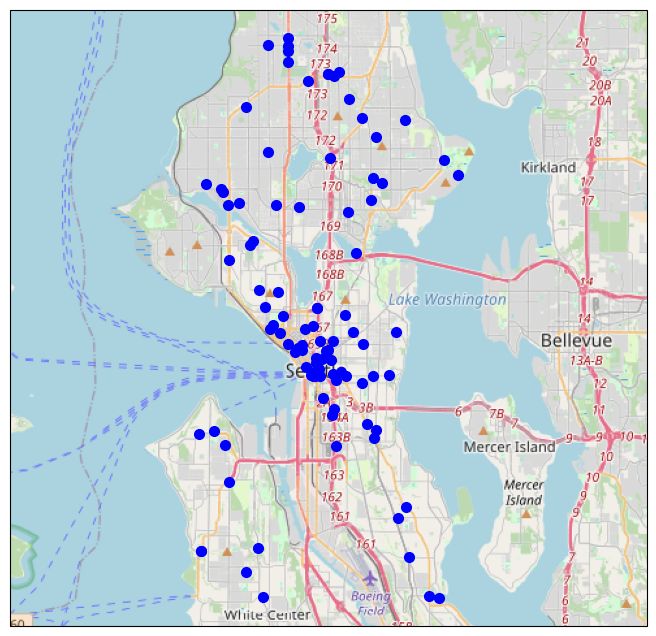

In [8]:
padding = 0.01
lon_min, lon_max = float(df["longitude"].min()) + padding * 10, float(df["longitude"].max()) - padding * 10
lat_min, lat_max = float(df["latitude"].min()) - padding, float(df["latitude"].max()) + padding

osm_tiles = cimgt.OSM()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': osm_tiles.crs})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.add_image(osm_tiles, 11)

for datum in data:
    ax.plot(
        float(datum['longitude']), 
        float(datum['latitude']), 
        'bo', markersize=7, transform=ccrs.Geodetic()
    )

plt.show()

Neat! Now, SFD live (sfdlive.com) has "richer" data than we have. They actually know which units were assigned to which event. Would it be possible for us to create a map of events that a specific unit responds to? And perhaps plot the route most likely taken between each event? To get an estimated sense of how far each unit drives every hour? That would be an interesting question to ask of the available data and one that could perhaps be useful for shift scheduling?

I've asked the owner of the website about what data source he uses. Perhaps I can try scraping his website for unit data? I note that you can query the website for a particular incident ID. `https://sfdlive.com/?id=F260019374` The resulting web page shows unit assignments. Can I do this with Python using the `requests` library?

In [9]:
incident_id = data[0]['incident_number']
incident_id

'F260019446'

In [20]:
def make_url_from_id(incident_id):
    sfd_url_template = "https://sfdlive.com/?id={}"
    incident_url = sfd_url_template.format(incident_id)
    return incident_url

make_url_from_id(incident_id)

'https://sfdlive.com/?id=F260019446'

In [11]:
response = requests.get(incident_url)
response

<Response [200]>

We'll use BeautifulSoup to parse the HTML contents in the response.

In [12]:
soup = BeautifulSoup(response.content, 'html.parser')

I need to extract a `span` with `class="span-units-dispatched"`

In [13]:
soup.find_all("span", class_="span-units-dispatched")

[]

Hmmm... the response does not contain the `span` I'm looking for. It seems SFDLive has JavaScript code which needs to be run by a web browser. That JavaScript code is responsible for actually fetching and displaying the data, including creating the `span` I want. I have a couple of options here.

1. I could simulate the browser using Playwright, but this will be slow for lots of data...

In [14]:
incident_url = 'https://sfdlive.com/?id=F260019445'

async def scrape():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        await page.goto(incident_url)
        element = await page.wait_for_selector(".span-units-dispatched")
        text = await element.text_content()
        await browser.close()
        return text

result = await scrape()
print(result)

E2* L4 


2. I could attempt to reverse engineer the obfuscated JavaScript to see how it fetches the data and try directly fetching that way!

In [15]:
poll_url = "https://sfdlive.com/api/data/poll/" + incident_id
response = requests.get(poll_url)
response.content

b'{"error":"Unauthorized Request"}'

Looks like more success with first method! Let's make it take a list of incident IDs and return a list of tuples of units!

In [29]:
async def get_list_of_units_dispatched(list_of_incident_ids):
    return_dict = {}
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        for incident_id in list_of_incident_ids:
            incident_url = make_url_from_id(incident_id)
            try:
                await page.goto(incident_url, timeout=5000)
                element = await page.wait_for_selector(".span-units-dispatched")
                text = await element.text_content()
                return_dict[incident_id] = text
            except:
                return_dict[incident_id] = "error"
        await browser.close()
    return return_dict

In [30]:
units_dispatched = await get_list_of_units_dispatched(df['incident_number'])
units_dispatched

{'F260019446': 'A10*',
 'F260019445': 'E2* L4 ',
 'F260019443': 'E5*',
 'F260019439': 'E31*',
 'F260019440': 'E25* E6 ',
 'F260019437': 'E38*',
 'F260019435': 'E8*',
 'F260019433': 'L11*',
 'F260019432': 'E9*',
 'F260019431': 'E32* M10 ',
 'F260019430': 'E25* L10 L4 ',
 'F260019429': 'E13* E36 ',
 'F260019428': 'H1*',
 'F260019427': 'E29*',
 'F260019425': 'A5*',
 'F260019419': 'A2*',
 'F260019416': 'B4 E18* E9 L8 MAR5 SAFT2 ',
 'F260019415': 'error',
 'F260019412': 'E16*',
 'F260019414': 'A25* M1 M17 ',
 'F260019411': 'E24* E31 ',
 'F260019409': 'E20*',
 'F260019407': 'A4* M18 ',
 'F260019405': 'H98*',
 'F260019401': 'E40*',
 'F260019402': 'A10* H99 L10 M32 ',
 'F260019398': 'B4 E22* L9 ',
 'F260019397': 'L10 L3* ',
 'F260019396': 'B5 E2* L4 ',
 'F260019395': 'L12*',
 'F260019392': 'E20*',
 'F260019391': 'A5 B2 E25* E36 E5 M28 M31 M44 SAFT2 ',
 'F260019389': 'E6* L10 ',
 'F260019388': 'E28*',
 'F260019386': 'L5*',
 'F260019385': 'E37*',
 'F260019384': 'E38 M17* ',
 'F260019383': 'E31*'